In [36]:
from sympy import init_printing
init_printing() 
from sympy import init_session
init_session() 
from sympy import *
from IPython.display import display


IPython console for SymPy 1.13.1 (Python 3.12.4-64-bit) (ground types: python)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.13.1/



In [49]:
# See if this quintic equation for R be solved algebraically:

a, b, c, d, e, f, R, RT, LT, LsT, Fsb, Kd1, Kd2, Kd3 = sp.symbols('a b c d e f R RT LT LsT Fsb Kd1 Kd2 Kd3')

LT = 100
RT = 0.05
LsT = 0.005
Kd1 = 0.0245
Kd2 = 0.1
Kd3 = 0.2



a = -Kd1**2*Kd3**2
b = Kd1**2*Kd3*(Kd1*Kd2 - 3*Kd1*Kd3 + Kd1*LT - 2*Kd1*LsT + Kd1*RT - Kd2*Kd3 - Kd3*LT - Kd3*LsT + Kd3*RT)
c = Kd1**2*(3*Kd1**2*Kd2*Kd3 - 3*Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 4*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + Kd1**2*LT*LsT - Kd1**2*LT*RT - Kd1**2*LsT**2 + Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - 2*Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 3*Kd1*Kd3*LsT*RT - Kd1*Kd3*RT**2 - Kd2*Kd3**2*LsT + Kd2*Kd3**2*RT)
d = Kd1**3*(3*Kd1**2*Kd2*Kd3 - Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 2*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + 2*Kd1**2*LT*LsT - 3*Kd1**2*LT*RT - Kd1**2*LsT**2 + 2*Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + 2*Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - 2*Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 6*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 - Kd1*LsT**3 + 2*Kd1*LsT**2*RT - Kd1*LsT*RT**2 - 2*Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
e = Kd1**4*(Kd1**2*Kd2*Kd3 + Kd1**2*Kd3*LT + Kd1**2*Kd3*RT + Kd1**2*LT*LsT - 3*Kd1**2*LT*RT + Kd1**2*LsT*RT - Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - Kd1*Kd3**2*LT + Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT + 3*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 + 2*Kd1*LsT**2*RT - 2*Kd1*LsT*RT**2 - Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
f = Kd1**5*RT*(-Kd1**2*LT - Kd1*Kd2*Kd3 + Kd1*Kd3*LT - Kd1*Kd3*RT - Kd1*LsT*RT + Kd2*Kd3**2)


eq = a*R**5 + b*R**4 + c*R**3 + d*R**2 + e*R + f

solution = sp.roots(eq, R)

print(solution)


{}


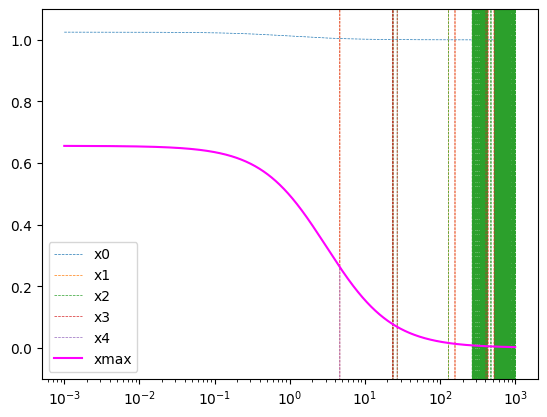

In [293]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the roots 

RT = 0.05           # [R]T parameter
LsT = 0.005           # [L]*T parameter
Kd1 = 0.0245        # Kd of the probe

Kd2 = 1

def quintic_numeric_R(LT, RT, LsT, Kd1, Kd2): 

    Kd3 = 100
    
    x0_array = []
    x1_array = []
    x2_array = []
    x3_array = []
    x4_array = []
    xmax_array = []

    for LT in LT:
        a = -Kd1**2*Kd3**2
        b = Kd1**2*Kd3*(Kd1*Kd2 - 3*Kd1*Kd3 + Kd1*LT - 2*Kd1*LsT + Kd1*RT - Kd2*Kd3 - Kd3*LT - Kd3*LsT + Kd3*RT)
        c = Kd1**2*(3*Kd1**2*Kd2*Kd3 - 3*Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 4*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + Kd1**2*LT*LsT - Kd1**2*LT*RT - Kd1**2*LsT**2 + Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - 2*Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 3*Kd1*Kd3*LsT*RT - Kd1*Kd3*RT**2 - Kd2*Kd3**2*LsT + Kd2*Kd3**2*RT)
        d = Kd1**3*(3*Kd1**2*Kd2*Kd3 - Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 2*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + 2*Kd1**2*LT*LsT - 3*Kd1**2*LT*RT - Kd1**2*LsT**2 + 2*Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + 2*Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - 2*Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 6*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 - Kd1*LsT**3 + 2*Kd1*LsT**2*RT - Kd1*LsT*RT**2 - 2*Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
        e = Kd1**4*(Kd1**2*Kd2*Kd3 + Kd1**2*Kd3*LT + Kd1**2*Kd3*RT + Kd1**2*LT*LsT - 3*Kd1**2*LT*RT + Kd1**2*LsT*RT - Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - Kd1*Kd3**2*LT + Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT + 3*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 + 2*Kd1*LsT**2*RT - 2*Kd1*LsT*RT**2 - Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
        f = Kd1**5*RT*(-Kd1**2*LT - Kd1*Kd2*Kd3 + Kd1*Kd3*LT - Kd1*Kd3*RT - Kd1*LsT*RT + Kd2*Kd3**2)

        p = [a, b, c, d, e, f] 
        roots = np.roots(p) 
        
        x0 = roots[0]
        x1 = roots[1]
        x2 = roots[2]
        x3 = roots[3]
        x4 = roots[4]
        xmax = max(roots)
        
            
            
        x0_array.append(x0/(Kd1+x0))
        x1_array.append(x1/(Kd1+x1))
        x2_array.append(x2/(Kd1+x2))
        x3_array.append(x3/(Kd1+x3))
        x4_array.append(x4/(Kd1+x4))
        xmax_array.append(xmax/(Kd1+xmax))
            
    return x0_array, x1_array, x2_array, x3_array, x4_array, xmax_array


x_curve = np.logspace(np.log10(0.001), np.log10(1000), 10000)

y_curve = quintic_numeric_R(x_curve, RT, LsT, Kd1, Kd2)

plt.plot(x_curve, y_curve[0], label="x0", linestyle="--", linewidth = 0.5)
plt.plot(x_curve, y_curve[1], label="x1", linestyle="--", linewidth = 0.5)
plt.plot(x_curve, y_curve[2], label="x2", linestyle="--", linewidth = 0.5)
plt.plot(x_curve, y_curve[3], label="x3", linestyle="--", linewidth = 0.5)
plt.plot(x_curve, y_curve[4], label="x4", linestyle="--", linewidth = 0.5)
plt.plot(x_curve, y_curve[5], label="xmax", linestyle="-", color="magenta")





plt.xscale("log")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()


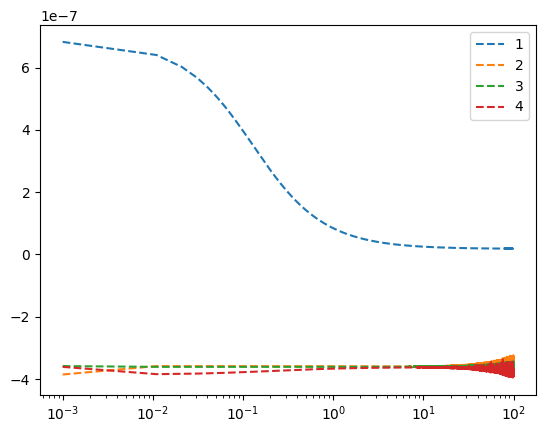

In [225]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the roots of the depressed quintic

RT = 0.05           # [R]T parameter
LsT = 0.005           # [L]*T parameter
Kd1 = 0.0245        # Kd of the probe

Kd2 = 0.1

def quintic_depressed_numeric_R(LT, RT, LsT, Kd1, Kd2): 

    Kd3 = 1
    
    x0_array = []
    x1_array = []
    x2_array = []
    x3_array = []
    x4_array = []

    for LT in LT:
        a = -Kd1**2*Kd3**2
        b = Kd1**2*Kd3*(Kd1*Kd2 - 3*Kd1*Kd3 + Kd1*LT - 2*Kd1*LsT + Kd1*RT - Kd2*Kd3 - Kd3*LT - Kd3*LsT + Kd3*RT)
        c = Kd1**2*(3*Kd1**2*Kd2*Kd3 - 3*Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 4*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + Kd1**2*LT*LsT - Kd1**2*LT*RT - Kd1**2*LsT**2 + Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - 2*Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 3*Kd1*Kd3*LsT*RT - Kd1*Kd3*RT**2 - Kd2*Kd3**2*LsT + Kd2*Kd3**2*RT)
        d = Kd1**3*(3*Kd1**2*Kd2*Kd3 - Kd1**2*Kd3**2 + 3*Kd1**2*Kd3*LT - 2*Kd1**2*Kd3*LsT + 3*Kd1**2*Kd3*RT + 2*Kd1**2*LT*LsT - 3*Kd1**2*LT*RT - Kd1**2*LsT**2 + 2*Kd1**2*LsT*RT - 3*Kd1*Kd2*Kd3**2 + 2*Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - 3*Kd1*Kd3**2*LT - Kd1*Kd3**2*LsT + 3*Kd1*Kd3**2*RT - 2*Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT - 2*Kd1*Kd3*LsT**2 + 6*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 - Kd1*LsT**3 + 2*Kd1*LsT**2*RT - Kd1*LsT*RT**2 - 2*Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
        e = Kd1**4*(Kd1**2*Kd2*Kd3 + Kd1**2*Kd3*LT + Kd1**2*Kd3*RT + Kd1**2*LT*LsT - 3*Kd1**2*LT*RT + Kd1**2*LsT*RT - Kd1*Kd2*Kd3**2 + Kd1*Kd2*Kd3*LsT - 3*Kd1*Kd2*Kd3*RT - Kd1*Kd3**2*LT + Kd1*Kd3**2*RT - Kd1*Kd3*LT*LsT + 3*Kd1*Kd3*LT*RT + 3*Kd1*Kd3*LsT*RT - 3*Kd1*Kd3*RT**2 + 2*Kd1*LsT**2*RT - 2*Kd1*LsT*RT**2 - Kd2*Kd3**2*LsT + 3*Kd2*Kd3**2*RT)
        f = Kd1**5*RT*(-Kd1**2*LT - Kd1*Kd2*Kd3 + Kd1*Kd3*LT - Kd1*Kd3*RT - Kd1*LsT*RT + Kd2*Kd3**2)

        
        
        # Depressed quintic equation
        # y**5 + p*y**3 + q*y**2 + r*y + s =0
        
        p = (5*a*c - 2*b**2) / 5*a**2
        q = (25*a**2*d - 15*a*b*c + 4*b**3) / 25*a**3
        r = (125*a**3*e - 50*a**2*b*d + 15*a*b**2*c - 3*b**4) / 125*a**4
        s = (3125*a**4*f - 625*a**3*b*e + 125*a**2*b**2*d - 25*a*b**3*c + 4*b**5) / 3125*a**5
        
        
        p = [1, 0, p, q, r, s] 
        roots = np.roots(p) 

       
        y0 = roots[0]
        y1 = roots[1]
        y2 = roots[2]
        y3 = roots[3]
        y4 = roots[4]


        x0 = y0 - (b/5*a)
        x1 = y1 - (b/5*a)
        x2 = y2 - (b/5*a)
        x3 = y3 - (b/5*a)
        x4 = y4 - (b/5*a)

        x0_array.append(x0/(Kd1+x0))
        x1_array.append(x1/(Kd1+x1))
        x2_array.append(x2/(Kd1+x2))
        x3_array.append(x3/(Kd1+x3))
        x4_array.append(x4/(Kd1+x4))

        
    return x0_array, x1_array, x2_array, x3_array, x4_array


x_curve = np.linspace(0.001, 100, 10000)

y_curve = quintic_depressed_numeric_R(x_curve, RT, LsT, Kd1, Kd2)

plt.plot(x_curve, y_curve[1], label="1", linestyle="--")
plt.plot(x_curve, y_curve[2], label="2", linestyle="--")
plt.plot(x_curve, y_curve[3], label="3", linestyle="--")
plt.plot(x_curve, y_curve[4], label="4", linestyle="--")




plt.xscale("log")
plt.legend()
#plt.ylim(-RT, RT)
plt.show()
